# The Inverse Problem: Log-Optimal Payouts from a Probability View

The previous notebook (*Option Price and Probability Duality*) established the duality both ways:

1. **prices → probability**: butterfly prices reveal the market-implied density $q(S_T)$
2. **payoff → portfolio**: any European payoff $g(S_T)$ is replicable with bonds + stock + calls

This notebook closes the loop with the **inverse problem**: *given that I disagree with the
market's density, what payoff should I buy?*

### The answer in one line

Maximize expected log wealth $\mathbf{E}_p[\log g(S_T)]$ over payoffs $g$, subject to the
budget constraint that the payoff's market price equals initial wealth $W$. By the FTAP the
price is $Z\,\mathbf{E}_q[g]$, so the Lagrangian gives:

$$g^*(S) \;=\; \frac{W}{Z}\cdot\frac{p(S)}{q(S)}$$

**Buy terminal wealth in proportion to how much more likely you think each price is than the
market does.** The resulting expected log growth is

$$\mathbf{E}_p\!\left[\log \tfrac{g^*}{W}\right] \;=\; \mathrm{KL}(p\,\|\,q) - \log Z$$

— your edge, in nats, is *literally the KL divergence* between your density and the market's.
No disagreement, no trade: if $p=q$ the optimal payoff is a bond.

### The thesis being expressed

Semiconductor designers and manufacturers (NVDA, AMD, TSM, AVGO, and the SOXX/SMH baskets)
have, over long stretches, delivered realized return distributions sitting to the *right* of
what their option prices implied — the market's risk-neutral density, which is drift-pinned to
the risk-free rate, systematically understated the sector's realized drift and right tail. Here
$p$ is built from a **block bootstrap of actual historical h-day returns** — the thesis is
encoded as data, not as a hand-drawn curve.

### Why an ETF (SOXX) rather than a single name

The thesis is about the *industry*, so the cleanest expression is a sector basket:
SOXX/SMH carry the designers (NVDA, AMD, AVGO) and manufacturers (TSM, ASML, MU, INTC)
together, and an ETF has no single-name earnings print sitting inside the option's life —
single-stock densities around earnings go bimodal, which is a different (and interesting)
trade than the steady-state sector view. Liquidity note: **SMH options are considerably more
liquid than SOXX's**; SOXX is used as the running example here, but for execution SMH is
likely the better vehicle — one config change in the app.

> **Data note.** This run uses `payout_lab`'s synthetic provider (SVI smile, fat-tailed
> history calibrated ETF-like: lower vol and drift than a single semi name) so the notebook
> executes offline. With `MASSIVE_API_KEY` set in your
> environment, `get_provider()` automatically switches to live Massive (formerly Polygon.io)
> chains and price history — same code, real quotes. See `APP_DESIGN.md` for the app plan.

> **Not investment advice; a research prototype.** Density-ratio payoffs lose money often and
> win big rarely — that is what "log-optimal" looks like. Full Kelly is famously aggressive;
> the fraction parameter below matters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import payout_lab as pl

# palette: colorblind-validated, matches the repo review doc
INK, MUT, GRID = "#0b0b0b", "#898781", "#e1e0d9"
BLUE, GREEN, MAGENTA, YELLOW = "#2a78d6", "#008300", "#e87ba4", "#eda100"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.grid": True, "grid.color": GRID, "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUT, "ytick.color": MUT, "axes.labelcolor": "#52514e",
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "legend.frameon": False, "lines.linewidth": 2.0, "figure.figsize": (8.5, 3.8),
})

## 1 · Pull the chain and extract the market's density $q$

`get_provider()` returns the live Massive client when a key is configured, otherwise the
synthetic stand-in. The implied density uses the noise-robust version of the
Breeden–Litzenberger pipeline: **OTM-stitched quotes** (puts below the forward converted to
synthetic calls via put–call parity $C = P + S - KZ$, calls above — always the liquid side of
the book) → spread-weighted spline of implied vols in log-moneyness → dense call curve →
second difference. Differencing raw quotes directly, as in the duality notebook, amplifies
bid/ask noise into negative densities; deep-ITM call quotes are the worst offenders, which is
exactly what the put side fixes.

In [2]:
TICKER, DTE, WEALTH = "SOXX", 45, 10_000

provider = pl.get_provider()          # MassiveProvider if MASSIVE_API_KEY is set
print("provider:", type(provider).__name__)

chain = provider.chain(TICKER, dte_target=DTE)
q = pl.implied_distribution(chain)

print(f"{TICKER}  spot={chain.spot:.2f}  expiry={chain.expiry}  "
      f"T={chain.T:.3f}y  Z={chain.Z:.4f}  strikes={len(chain.calls)}")
print(f"density diagnostics: negative mass clipped={q.clipped_mass:.4f}, "
      f"raw mass={q.raw_mass:.3f} (want ≈ 1)")
src_mix = pl.stitched_quotes(chain)["source"].value_counts().to_dict()
print(f"quote stitching: {src_mix} (puts quote the left side, calls the right)")
print(f"market-implied P({0.9*chain.spot:.0f} < S_T < {1.1*chain.spot:.0f}) = "
      f"{q.prob_between(0.9*chain.spot, 1.1*chain.spot):.1%}")

provider: SyntheticProvider
SOXX  spot=245.00  expiry=2026-09-02  T=0.123y  Z=0.9951  strikes=56
density diagnostics: negative mass clipped=0.0000, raw mass=0.993 (want ≈ 1)
quote stitching: {'call': 32, 'put': 24} (puts quote the left side, calls the right)
market-implied P(220 < S_T < 270) = 60.3%


## 2 · Build the subjective density $p$ from historical returns

Block bootstrap (5-day blocks, preserving short-range autocorrelation) of h-day compounded
log returns from ~8 years of daily closes, kernel-smoothed into a density over $S_T$. A
`drift_override` lets you haircut the historical drift if you believe the past overstates the
future edge — conviction should be a dial, not a boolean. We also form the
**fractional-Kelly blend** $p_f \propto p^f q^{1-f}$: since $(p_f/q) = (p/q)^f$, shrinking the
view toward the market is exactly fractional Kelly sizing.

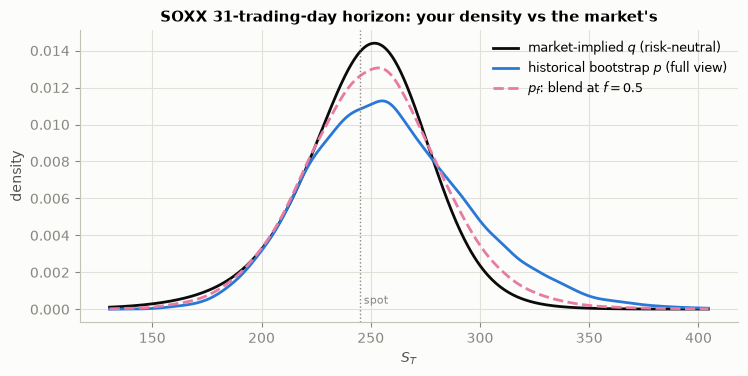

KL(p_f || q) = 0.0216 nats over 31 trading days → 17.5% annualized log-growth edge if the view is right


In [3]:
hist = provider.history(TICKER, years=8)
horizon = max(int(chain.T * 252), 1)

p_full = pl.historical_view(hist, horizon, chain.spot, q.grid, block=5, seed=1)
FRACTION = 0.5                        # half-Kelly conviction
p_view = pl.geometric_blend(p_full, q.pdf, q.grid, f=FRACTION)

fig, ax = plt.subplots()
ax.plot(q.grid, q.pdf, color=INK, label="market-implied $q$ (risk-neutral)")
ax.plot(q.grid, p_full, color=BLUE, label="historical bootstrap $p$ (full view)")
ax.plot(q.grid, p_view, color=MAGENTA, ls="--", label=f"$p_f$: blend at $f={FRACTION}$")
ax.axvline(chain.spot, color=MUT, lw=1, ls=":")
ax.text(chain.spot, ax.get_ylim()[1]*0.02, " spot", color=MUT, fontsize=8)
ax.set_xlabel("$S_T$"); ax.set_ylabel("density")
ax.set_title(f"{TICKER} {horizon*5//5}-trading-day horizon: your density vs the market's")
ax.legend(fontsize=9); plt.show()

kl = np.trapezoid(p_view * np.log(np.maximum(p_view,1e-300)/np.maximum(q.pdf,1e-300)), q.grid)
print(f"KL(p_f || q) = {kl:.4f} nats over {horizon} trading days "
      f"→ {kl/chain.T:.1%} annualized log-growth edge if the view is right")

The historical density sits right of the risk-neutral one (the drift gap)
with a fatter left tail (real crash frequency vs. lognormal-ish decay) — both disagreements
are tradable, and the optimal payoff will monetize *each* of them.

## 3 · The log-optimal payoff and its replication

$g^* = \frac{W}{Z}\frac{p_f}{q}$, with the tail ratio capped (payouts where no strikes trade
are unbuyable), then replicated on the **listed strikes actually quoted** by the exact
piecewise-linear decomposition: hold $g(K_0)$ in zero-coupon bonds and
$\Delta\text{slope}_i$ calls at each strike $K_i$ — the discrete form of
$g(S)=g(0)+g'(0)S+\int (S-K)^+ g''(K)\,dK$. Two execution upgrades: strikes with junk quotes
are dropped and the payoff pre-smoothed by one strike-width (bootstrap wiggle must not become
fake butterfly positions), and every leg below the forward is converted to an **OTM put**
through parity $(S-K)^+ = (K-S)^+ + S - K$ — same payoff at expiry, but you trade the tight
side of the book; the $S$ and $-K$ remainders accumulate into the stock and bond lines of the
ticket.

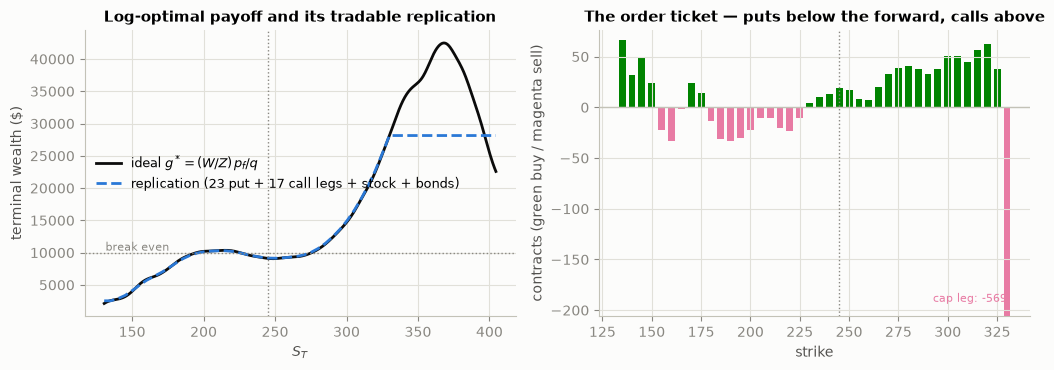

In [4]:
g = pl.log_optimal_payout(q.grid, p_view, q.pdf, wealth=WEALTH, Z=chain.Z, ratio_cap=8)
ticket = pl.replicate(q.grid, g, chain)
h = ticket.payoff(q.grid)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
ax = axes[0]
ax.plot(q.grid, g, color=INK, label="ideal $g^*=(W/Z)\,p_f/q$")
n_p = int((ticket.legs["type"]=="P").sum()); n_c = len(ticket.legs) - n_p
ax.plot(q.grid, h, color=BLUE, ls="--",
        label=f"replication ({n_p} put + {n_c} call legs + stock + bonds)")
ax.axhline(WEALTH, color=MUT, lw=1, ls=":"); ax.text(q.grid[2], WEALTH*1.03, "break even", color=MUT, fontsize=8)
ax.axvline(chain.spot, color=MUT, lw=1, ls=":")
ax.set_xlabel("$S_T$"); ax.set_ylabel("terminal wealth ($)")
ax.set_title("Log-optimal payoff and its tradable replication"); ax.legend(fontsize=9)

ax = axes[1]
qty = ticket.legs["qty"].to_numpy()
strikes_ = ticket.legs["strike"].to_numpy()
colors = [GREEN if x >= 0 else MAGENTA for x in qty]
ax.bar(strikes_, qty, width=0.7*np.median(np.diff(strikes_)), color=colors)
ax.axhline(0, color="#c3c2b7", lw=1); ax.axvline(chain.spot, color=MUT, lw=1, ls=":")
# the boundary cap leg dwarfs the body — clip the axis and label it instead
lim = 4 * np.percentile(np.abs(qty), 90)
ax.set_ylim(max(qty.min(), -lim), min(qty.max(), lim) * 1.15)
for s, x in zip(strikes_, qty):
    if x < -lim:
        ax.annotate(f"cap leg: {x:,.0f}", (s, -lim*0.93), ha="right", fontsize=8, color=MAGENTA)
ax.set_xlabel("strike"); ax.set_ylabel("contracts (green buy / magenta sell)")
ax.set_title("The order ticket — puts below the forward, calls above")
plt.tight_layout(); plt.show()

Read the ticket left to right: **long OTM puts** in the left wing (the fat crash tail your
history says the market underprices), **short options through the body** (selling the market
the outcomes it rates likeliest — where $q > p$), **long OTM calls** in the right wing (the
underpriced-upside thesis), all floating on a bond/stock floor. It is a short broad butterfly
plus a wing tilt — the direct generalization of the single butterflies in the duality
notebook, with sizes chosen by the density ratio instead of by hand, and each wing executed
in its liquid instrument. The one outsized position is the **cap leg** at the top strike: it
kills the payoff's slope above the last liquid strike, capping terminal wealth there (the
dashed flat in the left panel). That cap is what bounds the position's liability — in
production you would choose it deliberately (accept the cap, or extend the strip while
quotes stay usable) rather than inherit it from a liquidity filter.

In [5]:
print(f"bonds (face value at expiry): ${ticket.bonds:,.0f}   "
      f"stock: {ticket.stock:,.2f} shares")
display(ticket.legs.assign(side=np.where(ticket.legs.qty>=0, "BUY", "SELL"))
        [["type","strike","side","qty","mid","cost"]].round(2))
summary = pl.summarize(q.grid, p_view, q.pdf, g, ticket, chain, wealth=WEALTH)
display(summary.round(4).to_frame("value"))

bonds (face value at expiry): $10,823   stock: -6.77 shares


,type,strike,side,qty,mid,cost
0,P,135.0,BUY,66.36,0.26,17.52
1,P,140.0,BUY,31.93,0.32,10.13
2,P,145.0,BUY,49.39,0.36,17.98
3,P,150.0,BUY,24.06,0.43,10.46
4,P,155.0,SELL,-22.61,0.51,-11.47
5,P,160.0,SELL,-33.24,0.60,-19.88
6,P,165.0,SELL,-1.71,0.69,-1.19
7,P,170.0,BUY,23.64,0.81,19.22
8,P,175.0,BUY,14.45,0.95,13.74
9,P,180.0,SELL,-13.13,1.11,-14.63


,value
budget W,10000.0000
replication cost,9778.4814
expected log growth (ideal),0.0266
expected log growth (replicated),0.0501
annualized (replicated),0.4067
P(lose money) under your view,0.5444
P(lose money) market-implied,0.5970
option legs,40.0000


Notes on the summary block:

- **Replication cost vs budget** — the gap is discretization + the flat-tail extension; in a
  live app you'd scale the ticket to the exact budget and show slippage vs mid. Growth
  numbers are per dollar of *actual* cost, so "replicated" can even beat "ideal" when the
  replication comes in under budget — compare them as rates, not as a ranking.
- **P(lose money) is high under both densities.** That's not a bug: the log-optimal payoff
  under a right-shifted view loses small most of the time and wins large in the favored
  region. This is exactly why the fraction dial exists.
- The **replicated** growth is well below the **ideal** KL bound — the cost of the ratio cap,
  finite strikes, and smoothing. The gap is worth monitoring in the app as an "implementation
  efficiency" metric.

## 4 · Conviction as a dial: the Kelly fraction

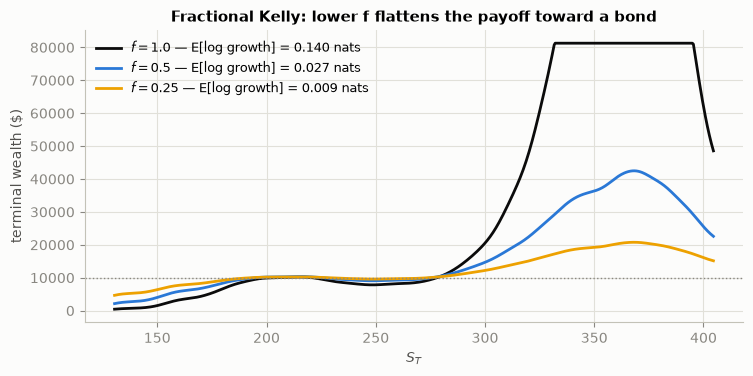

In [6]:
fig, ax = plt.subplots()
for f, c in [(1.0, INK), (0.5, BLUE), (0.25, YELLOW)]:
    pf = pl.geometric_blend(p_full, q.pdf, q.grid, f=f)
    gf = pl.log_optimal_payout(q.grid, pf, q.pdf, wealth=WEALTH, Z=chain.Z, ratio_cap=8)
    growth = pl.expected_log_growth(q.grid, pf, gf, WEALTH)
    ax.plot(q.grid, gf, color=c, label=f"$f={f}$ — E[log growth] = {growth:.3f} nats")
ax.axhline(WEALTH, color=MUT, lw=1, ls=":")
ax.set_xlabel("$S_T$"); ax.set_ylabel("terminal wealth ($)")
ax.set_title("Fractional Kelly: lower f flattens the payoff toward a bond")
ax.legend(fontsize=9); plt.show()

## 5 · From notebook to app

Everything above is a function call into `payout_lab/`, deliberately: the notebook is the
specification for a small app. The plan (full detail in **`APP_DESIGN.md`**):

- **Data**: Massive (ex-Polygon.io) REST — chain snapshot (both sides of the book) + daily
  aggregates — behind the `MassiveProvider` already in the package; set `MASSIVE_API_KEY` and
  this notebook re-runs on live quotes unchanged. American-exercise caveat: SOXX/SMH options
  are American-style; the European math here ignores early-exercise premium (small for the
  OTM-dominated tickets this produces, and avoidable entirely with XSP).
- **UI**: a small Streamlit app (ticker, expiry, Kelly fraction, drift haircut, budget) →
  density comparison, payoff, order ticket. Skeleton in `payout_app.py`.
- **Validating the thesis** (the important part): before betting on "the market undervalues
  semis," backtest it — for each month in history, extract $q$ from that day's chain, record
  the realized $S_T$, and compare log scores $\log p(S_T)$ vs $\log q(S_T)$. A persistently
  positive average difference *is* the monetizable KL edge, measured out-of-sample, per
  ticker. That backtest needs exactly one thing this environment lacks: historical option
  chains — which is the Massive subscription's job.